   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 131.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.4/235.4 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 72.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.6/293.6 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 132.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 21.5 MB/s eta 0:00:00
✓ All libraries imported

1. LOADING LC 10% CREDIT DEFAULT DATASET
✓ LC 10% loaded: (50000, 10)
  Default rate: 10.00%
  Class distribution: {0: 45000, 1: 5000}


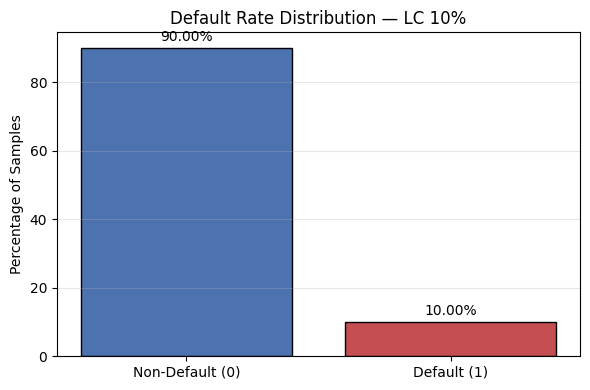


2. PREPROCESSING
  Categorical features: 4
  Numeric features: 5
  Processed features after OHE: 81

3. TUNING / EVALUATION SPLIT
  Tuning pool:     10000 samples
  Evaluation pool: 40000 samples
  Tuning default rate:     10.00%
  Evaluation default rate: 10.00%

4. HYPERPARAMETER OPTIMISATION (RandomizedSearchCV)

  === Tuning RF ===
Fitting 4 folds for each of 15 candidates, totalling 60 fits
  Best RF CV AUC: 0.6635
  Best params: {'clf__n_estimators': 200, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 4, 'clf__max_features': 'sqrt', 'clf__max_depth': 11, 'clf__class_weight': 'balanced'}

  === Tuning XGB ===
Fitting 4 folds for each of 15 candidates, totalling 60 fits
  Best XGB CV AUC: 0.6647
  Best params: {'clf__subsample': 0.65, 'clf__scale_pos_weight': 3, 'clf__reg_lambda': 0.1, 'clf__n_estimators': 120, 'clf__max_depth': 4, 'clf__learning_rate': 0.02, 'clf__colsample_bytree': 1.0}

  === Tuning LGB ===
Fitting 4 folds for each of 15 candidates, totalling 60 fits
  B

In [1]:
"""
LC 10% CREDIT DEFAULT — COMPLETE EXPERIMENT
Dataset: 50,000 obs, features from Lending Club, 10.00% default
Output: LC_result.csv, LC_result_nemenyi.csv, LC_result_wilcoxon.csv, LC_result_correlation.csv
"""

import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 0. INSTALL & IMPORTS
# ============================================================
!pip install --quiet xgboost lightgbm imbalanced-learn shap networkx seaborn scikit_posthocs numba

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    StratifiedKFold, train_test_split, RandomizedSearchCV
)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
from sklearn.utils.class_weight import compute_class_weight
from sklearn.pipeline import Pipeline

import xgboost as xgb
import lightgbm as lgb

from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

import shap
import networkx as nx
from sklearn.cluster import AgglomerativeClustering
from scipy.spatial.distance import cosine

import scikit_posthocs as sp
from scipy.stats import friedmanchisquare, wilcoxon, spearmanr, kendalltau

plt.style.use('default')
sns.set_palette("deep")
np.random.seed(42)
RANDOM_STATE = 42

print("✓ All libraries imported")

# ============================================================
# 1. LOAD DATA — LC 10% Dataset (Modified path & target)
# ============================================================
print("\n" + "="*80)
print("1. LOADING LC 10% CREDIT DEFAULT DATASET")
print("="*80)

df = pd.read_csv("/content/LC_50K_10%.csv")

# Identify target column
if 'Default' in df.columns:
    df = df.rename(columns={'Default': 'target'})
elif 'default' in df.columns:
    df = df.rename(columns={'default': 'target'})

# Drop ID/leakage columns (custom for LC)
cols_to_drop = ['id', 'issue_d', 'zip_code', 'title', 'desc']
cols_to_drop = [c for c in cols_to_drop if c in df.columns]
df = df.drop(columns=cols_to_drop)

# Handle missing values (LC specific)
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in ['int64', 'float64']:
            df[col].fillna(df[col].median(), inplace=True)
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)

print(f"✓ LC 10% loaded: {df.shape}")
print(f"  Default rate: {df['target'].mean()*100:.2f}%")
print(f"  Class distribution: {df['target'].value_counts().to_dict()}")

# Default distribution plot
default_counts = df['target'].value_counts().sort_index()
default_pct = default_counts / len(df) * 100

plt.figure(figsize=(6, 4))
bars = plt.bar(['Non-Default (0)', 'Default (1)'], default_pct.values,
               color=['#4C72B0', '#C44E52'], edgecolor='black')
plt.bar_label(bars, fmt="%.2f%%", padding=3)
plt.ylabel("Percentage of Samples")
plt.title("Default Rate Distribution — LC 10%")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("LC_default_distribution.png", dpi=150)
plt.show()

# ============================================================
# 2. PREPROCESSING
# ============================================================
print("\n" + "="*80)
print("2. PREPROCESSING")
print("="*80)

y_all = df['target']
X_all = df.drop('target', axis=1)

# Identify categorical features (LC specific)
categorical_features = X_all.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_features = X_all.select_dtypes(include=[np.number]).columns.tolist()

# Convert all categorical to string for OHE
for col in categorical_features:
    X_all[col] = X_all[col].astype(str)

cat_categories = [sorted(X_all[col].unique()) for col in categorical_features]

print(f"  Categorical features: {len(categorical_features)}")
print(f"  Numeric features: {len(numeric_features)}")

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first', sparse_output=False,
                          categories=cat_categories, handle_unknown='ignore'),
     categorical_features),
    ('num', StandardScaler(), numeric_features)
])

# Fit on full data ONLY for feature_names extraction
preprocessor.fit(X_all)
feature_names = preprocessor.get_feature_names_out()
d = len(feature_names)
print(f"  Processed features after OHE: {d}")

# ============================================================
# 3. TUNING / EVALUATION SPLIT (CRITICAL FIX — NO LEAKAGE)
# ============================================================
print("\n" + "="*80)
print("3. TUNING / EVALUATION SPLIT")
print("="*80)

# LC = 50,000 samples → 20% for tuning = 10,000
SMALL_DATASET_THRESHOLD = 2000
tune_fraction = 0.5 if len(X_all) <= SMALL_DATASET_THRESHOLD else 0.2

X_tune, X_eval, y_tune, y_eval = train_test_split(
    X_all, y_all,
    test_size=(1 - tune_fraction),
    stratify=y_all,
    random_state=RANDOM_STATE
)

print(f"  Tuning pool:     {len(X_tune)} samples")
print(f"  Evaluation pool: {len(X_eval)} samples")
print(f"  Tuning default rate:     {y_tune.mean()*100:.2f}%")
print(f"  Evaluation default rate: {y_eval.mean()*100:.2f}%")

# ============================================================
# 4. HYPERPARAMETER OPTIMISATION
# ============================================================
print("\n" + "="*80)
print("4. HYPERPARAMETER OPTIMISATION (RandomizedSearchCV)")
print("="*80)

def tune_model(X, y, model_name, n_iter=15):
    print(f"\n  === Tuning {model_name} ===")
    numeric = X.select_dtypes(include=np.number).columns.tolist()
    cat = X.select_dtypes(exclude=np.number).columns.tolist()

    prep = ColumnTransformer([
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore',
                              sparse_output=False), cat),
        ('num', StandardScaler(), numeric)
    ], remainder='passthrough')

    if model_name == "RF":
        base = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
        params = {
            'clf__n_estimators':      [80, 120, 160, 200, 250],
            'clf__max_depth':         [5, 8, 11, 15, None],
            'clf__min_samples_split': [2, 5, 10],
            'clf__min_samples_leaf':  [1, 2, 4],
            'clf__max_features':      ['sqrt', 'log2', 0.6],
            'clf__class_weight':      ['balanced', None]
        }
    elif model_name == "XGB":
        base = xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric='auc', verbosity=0)
        params = {
            'clf__n_estimators':      [80, 120, 180, 250],
            'clf__learning_rate':     [0.008, 0.02, 0.05, 0.12],
            'clf__max_depth':         [4, 6, 8, 10],
            'clf__subsample':         [0.65, 0.8, 0.95],
            'clf__colsample_bytree':  [0.6, 0.8, 1.0],
            'clf__reg_lambda':        [0.1, 1, 5],
            'clf__scale_pos_weight':  [1, 2, 3, 5]
        }
    elif model_name == "LGB":
        base = lgb.LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)
        params = {
            'clf__n_estimators':      [80, 120, 180, 250],
            'clf__learning_rate':     [0.008, 0.02, 0.05, 0.12],
            'clf__max_depth':         [4, 6, 8, 10],
            'clf__num_leaves':        [20, 40, 80, 150],
            'clf__subsample':         [0.65, 0.8, 0.95],
            'clf__colsample_bytree':  [0.6, 0.8, 1.0],
            'clf__reg_lambda':        [0.1, 1, 5],
            'clf__class_weight':      ['balanced', None]
        }

    pipe = Pipeline([('prep', prep), ('clf', base)])
    search = RandomizedSearchCV(
        pipe, param_distributions=params, n_iter=n_iter,
        cv=StratifiedKFold(4, shuffle=True, random_state=RANDOM_STATE),
        scoring='roc_auc', n_jobs=-1, random_state=RANDOM_STATE, verbose=1
    )
    search.fit(X, y.astype(np.int64))
    print(f"  Best {model_name} CV AUC: {search.best_score_:.4f}")
    print(f"  Best params: {search.best_params_}")
    return search.best_estimator_, search.best_params_, search.best_score_

best_rf,  rf_params,  rf_auc  = tune_model(X_tune, y_tune, "RF")
best_xgb, xgb_params, xgb_auc = tune_model(X_tune, y_tune, "XGB")
best_lgb, lgb_params, lgb_auc = tune_model(X_tune, y_tune, "LGB")

print("\n  ── Best CV AUCs for Table 2.2 ──")
print(f"  RF:  {rf_auc:.4f}")
print(f"  XGB: {xgb_auc:.4f}")
print(f"  LGB: {lgb_auc:.4f}")

# ============================================================
# 5. MODEL CONFIGURATION
# ============================================================
print("\n" + "="*80)
print("5. CONFIGURING MODELS")
print("="*80)

def strip_prefix(d, prefix="clf__"):
    return {k[len(prefix):]: v for k, v in d.items() if k.startswith(prefix)}

BEST_PARAMS = {
    'RF':  strip_prefix(rf_params),
    'XGB': strip_prefix(xgb_params),
    'LGB': strip_prefix(lgb_params)
}

BEST_PARAMS['RF'].update({'random_state': RANDOM_STATE, 'n_jobs': -1})
BEST_PARAMS['XGB'].update({'random_state': RANDOM_STATE, 'eval_metric': 'auc', 'verbosity': 0})
BEST_PARAMS['LGB'].update({'random_state': RANDOM_STATE, 'verbose': -1})

models = {
    'RF':  RandomForestClassifier(**BEST_PARAMS['RF']),
    'XGB': xgb.XGBClassifier(**BEST_PARAMS['XGB']),
    'LGB': lgb.LGBMClassifier(**BEST_PARAMS['LGB'])
}

for mname, m in models.items():
    print(f"\n  [{mname}] {m.get_params()}")

# ============================================================
# 6. IMBALANCE STRATEGIES
# ============================================================
print("\n" + "="*80)
print("6. IMBALANCE HANDLING")
print("="*80)

X = X_eval.reset_index(drop=True)
y = y_eval.reset_index(drop=True)

resamplers = {
    'None':          None,
    'SMOTE':         SMOTE(random_state=RANDOM_STATE),
    'SMOTETomek':    SMOTETomek(random_state=RANDOM_STATE),
    'CostSensitive': 'cost'
}

class_weight_dict = {
    int(cls): float(w)
    for cls, w in zip(np.unique(y), compute_class_weight('balanced', classes=np.unique(y), y=y))
}

print(f"  Strategies: {list(resamplers.keys())}")
print(f"  Class weights: {class_weight_dict}")
print(f"  Evaluation samples: {len(X)}")

# ============================================================
# 7. DOMAIN GROUPS — LC 10% (MODIFIED for LC features)
# ============================================================
print("\n" + "="*80)
print("7. DOMAIN GROUPS (LC 10%)")
print("="*80)

def build_domain_groups_lc(fnames):
    groups = {
        "EmploymentIncome":    [],
        "LoanTerms":           [],
        "CreditHistory":       [],
        "Delinquency":         [],
        "Utilization":         [],
        "Purpose":             [],
        "AssetsCollateral":    [],
        "Location":            []
    }
    for i, name in enumerate(fnames):
        ln = name.lower()
        if any(k in ln for k in ["experience", "emp_length", "annual_inc", "revenue", "dti", "fico"]):
            groups["EmploymentIncome"].append(i)
        elif any(k in ln for k in ["loan_amnt", "term", "installment", "int_rate"]):
            groups["LoanTerms"].append(i)
        elif any(k in ln for k in ["open_acc", "total_acc", "revol_bal", "inq_last"]):
            groups["CreditHistory"].append(i)
        elif any(k in ln for k in ["delinq", "pub_rec", "collections", "chargeoff"]):
            groups["Delinquency"].append(i)
        elif any(k in ln for k in ["revol_util", "utilization"]):
            groups["Utilization"].append(i)
        elif "purpose" in ln:
            groups["Purpose"].append(i)
        elif "home_ownership" in ln:
            groups["AssetsCollateral"].append(i)
        elif "addr_state" in ln:
            groups["Location"].append(i)
    return {g: v for g, v in groups.items() if len(v) > 0}

domain_groups = build_domain_groups_lc(feature_names)
for g, feats in domain_groups.items():
    print(f"  {g}: {len(feats)} features")

# ============================================================
# 8. EXPLANATION METHODS
# ============================================================
print("\n" + "="*80)
print("8. EXPLANATION METHODS")
print("="*80)

def stratified_explanation_sample(X_te, y_te, n=30, random_state=42, min_pos=5):
    X_te = X_te.reset_index(drop=True)
    y_te = pd.Series(y_te).reset_index(drop=True)
    n = min(n, len(X_te))
    pos_idx = y_te[y_te == 1].index
    neg_idx = y_te[y_te == 0].index
    n_pos = min(min_pos, len(pos_idx), n)
    n_neg = n - n_pos
    X_pos = (X_te.loc[pos_idx].sample(n=n_pos, random_state=random_state)
             if n_pos > 0 else X_te.iloc[0:0])
    X_neg = (X_te.loc[neg_idx].sample(n=n_neg, random_state=random_state)
             if n_neg > 0 else X_te.iloc[0:0])
    return pd.concat([X_pos, X_neg]).sample(frac=1, random_state=random_state)


def get_shap_values(pipe, X_test):
    clf = pipe.named_steps['clf']
    X_proc = pipe.named_steps['prep'].transform(X_test)
    try:
        explainer = shap.TreeExplainer(clf)
        sv = explainer.shap_values(X_proc)
        if isinstance(sv, list): return sv[1]
        elif sv.ndim == 3: return sv[:, :, 1]
        return sv
    except Exception as e:
        print(f"    SHAP fallback: {e}")
        return np.zeros((len(X_test), X_proc.shape[1]))


def compute_banzhaf(pipe, X_test, n_samples=2, max_instances=2):
    clf = pipe.named_steps['clf']
    X_proc = pipe.named_steps['prep'].transform(X_test)
    n_feat = X_proc.shape[1]
    n_inst = min(max_instances, X_proc.shape[0])
    mat = np.zeros((n_inst, n_feat))
    for i in range(n_inst):
        x = X_proc[i:i+1]
        for f in range(n_feat):
            contrib = []
            for _ in range(n_samples):
                coal = np.random.binomial(1, 0.5, n_feat)
                x_with = x.copy(); x_with[0, f] = x[0, f] * coal[f]
                p1 = clf.predict_proba(x_with)[0, 1]
                x_without = x.copy(); x_without[0, f] = 0
                p0 = clf.predict_proba(x_without)[0, 1]
                contrib.append(p1 - p0)
            mat[i, f] = np.mean(contrib)
    return mat


def compute_myerson(pipe, X_test, G, alpha=0.5):
    shap_vals = get_shap_values(pipe, X_test)
    shap_mean = shap_vals.mean(axis=0)
    d_local = len(shap_mean)
    phi = np.zeros(d_local)
    for i in range(d_local):
        neighbors = list(G.neighbors(i)) if i in G.nodes() else []
        if len(neighbors) == 0:
            phi[i] = shap_mean[i]
        else:
            neighbor_vals = [shap_mean[j] for j in neighbors if j < d_local]
            neighbor_mean = np.mean(neighbor_vals) if neighbor_vals else 0.0
            phi[i] = (1 - alpha) * shap_mean[i] + alpha * neighbor_mean
    n_tile = min(30, len(X_test))
    return np.tile(phi, (n_tile, 1)), shap_vals, shap_mean


def build_data_groups(X_proc, n_groups=5):
    try:
        X_proc = np.nan_to_num(X_proc)
        corr = np.corrcoef(X_proc.T)
        corr = np.nan_to_num(corr); np.fill_diagonal(corr, 1.0)
        dist = np.clip(1 - np.abs(corr), 0.0, 2.0)
        n_feat = X_proc.shape[1]
        if n_feat < n_groups: n_groups = max(2, n_feat // 2)
        clustering = AgglomerativeClustering(n_clusters=n_groups, metric='precomputed', linkage='average')
        labels = clustering.fit_predict(dist)
        groups = {}
        for idx, lab in enumerate(labels): groups.setdefault(f"Data_Cluster_{lab}", []).append(idx)
        return groups, np.abs(corr)
    except Exception as e:
        print(f"    Data grouping fallback: {e}")
        return {"Data_Default": list(range(X_proc.shape[1]))}, np.eye(X_proc.shape[1])


def build_model_groups(shap_vals, n_groups=5):
    try:
        shap_vals = np.nan_to_num(shap_vals)
        if shap_vals.ndim == 1: shap_vals = shap_vals.reshape(1, -1)
        n_instances, n_features = shap_vals.shape
        if n_instances < 2 or n_features < 2:
            return {"Model_Default": list(range(n_features))}, np.eye(n_features)
        corr = np.corrcoef(shap_vals.T)
        corr = np.nan_to_num(corr); np.fill_diagonal(corr, 1.0)
        dist = np.clip(1 - np.abs(corr), 0.0, 2.0)
        if n_features < n_groups: n_groups = max(2, n_features // 2)
        clustering = AgglomerativeClustering(n_clusters=n_groups, metric='precomputed', linkage='average')
        labels = clustering.fit_predict(dist)
        groups = {}
        for idx, lab in enumerate(labels): groups.setdefault(f"Model_Group_{lab}", []).append(idx)
        return groups, np.abs(corr)
    except Exception as e:
        print(f"    Model grouping fallback: {e}")
        n_features = shap_vals.shape[1] if shap_vals.ndim > 1 else shap_vals.shape[0]
        return {"Model_Default": list(range(n_features))}, np.eye(n_features)


def owen_from_phi(phi, groups):
    d_local = len(phi); out = np.zeros(d_local)
    for _, feats in groups.items():
        valid_feats = [f for f in feats if f < d_local]
        if not valid_feats: continue
        total = np.sum(np.abs(phi[valid_feats])); per = total / len(valid_feats)
        for f in valid_feats:
            out[f] = (np.sign(phi[f]) if phi[f] != 0 else 1) * per
    return out


def adaptive_owen_myerson(phi_my):
    d_local = len(phi_my); total = np.sum(np.abs(phi_my)); per = total / d_local
    return np.array([(np.sign(x) if x != 0 else 1) * per for x in phi_my])


def compute_Q(groups, dep):
    try:
        d_local = dep.shape[0]; group_id = np.full(d_local, -1)
        for gid, (_, feats) in enumerate(groups.items()):
            for f in feats:
                if f < d_local: group_id[f] = gid
        within, across = [], []
        for i in range(d_local):
            for j in range(i+1, d_local):
                if group_id[i] == group_id[j] and group_id[i] != -1: within.append(dep[i, j])
                elif group_id[i] != -1 and group_id[j] != -1: across.append(dep[i, j])
        if not within or not across: return np.nan
        return float(np.mean(within) / np.mean(across)) if np.mean(across) != 0 else np.nan
    except: return np.nan

print("✓ All explanation methods defined")

# ============================================================
# 9. INTERPRETABILITY METRICS
# ============================================================
print("\n" + "="*80)
print("9. INTERPRETABILITY METRICS")
print("="*80)

def stability_cv(expl_list):
    if len(expl_list) < 2: return 1.0
    arr = np.stack([np.abs(e) for e in expl_list])
    mean = arr.mean(axis=0) + 1e-8
    return float(np.mean(arr.std(axis=0) / mean))

def kuncheva_index(expl_list, k=10):
    if len(expl_list) < 2: return 0.0
    sets = []; d_local = None
    for exp in expl_list:
        imp = np.abs(exp).mean(axis=0).ravel()
        if d_local is None: d_local = len(imp)
        sets.append(set(np.argsort(imp)[-min(k, len(imp)):].tolist()))
    if len(sets) < 2 or d_local is None: return 0.0
    ki_vals = []
    for i in range(len(sets)):
        for j in range(i+1, len(sets)):
            ki = (len(sets[i]&sets[j]) - (k**2)/d_local) / (k - (k**2)/d_local) if k != d_local else 0.0
            ki_vals.append(max(min(ki, 1.0), -1.0))
    return float(np.mean(ki_vals)) if ki_vals else 0.0

def cosine_directional_consistency(expl_list):
    if len(expl_list) < 2: return 0.0
    mean_vecs = [np.mean(e, axis=0).ravel() for e in expl_list]
    sims = [1 - cosine(mean_vecs[p], mean_vecs[s])
            for p in range(len(mean_vecs)) for s in range(p+1, len(mean_vecs))]
    return float(np.mean(sims)) if sims else 0.0

def interpretability_score(cv_val, kun_val, cos_val, beta=1/3):
    return beta * (1 - cv_val) + beta * kun_val + beta * cos_val

def normalize(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-8)

def performance_interpretability_score(auc_series, I_series, alpha=0.5):
    return alpha * normalize(auc_series) + (1 - alpha) * normalize(I_series)

print("✓ All metrics defined")

# ============================================================
# 10. MAIN EXPERIMENT — 4-Fold Stratified CV
# ============================================================
print("\n" + "="*80)
print("10. RUNNING MAIN EXPERIMENT — 7 METHODS × 3 MODELS × 4 SAMPLERS")
print("="*80)

cv_folds = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
all_records = []
all_explanations = {}

method_order = ['SHAP', 'Banzhaf', 'Myerson', 'Owen-Domain', 'Owen-Data', 'Owen-Model', 'R-Myerson']

total_configs = len(models) * len(resamplers)
config_count = 0

for mname, model in models.items():
    for sname, sampler in resamplers.items():
        config_count += 1
        print(f"\n  [{config_count}/{total_configs}] {mname} | {sname}")

        aucs = []
        shap_runs, banzhaf_runs, myerson_runs = [], [], []
        owen_dom_runs, owen_data_runs, owen_model_runs, r_myerson_runs = [], [], [], []
        Q_dom_list, Q_data_list, Q_model_list = [], [], []

        for fold, (train_idx, test_idx) in enumerate(cv_folds.split(X, y), 1):
            X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
            y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

            fold_prep_analysis = clone(preprocessor)
            X_tr_proc = fold_prep_analysis.fit_transform(X_tr)

            fold_prep_pipe = clone(preprocessor)

            # Myerson graph (training data only, τ=0.25)
            corr_tr = np.nan_to_num(np.corrcoef(X_tr_proc.T))
            G_myerson = nx.Graph()
            G_myerson.add_nodes_from(range(d))
            for i in range(d):
                for j in range(i+1, d):
                    if abs(corr_tr[i, j]) >= 0.25:
                        G_myerson.add_edge(i, j)

            # Build pipeline
            pipe = ImbPipeline([('prep', fold_prep_pipe), ('clf', clone(model))])

            if sampler and sampler != 'cost':
                pipe.steps.insert(1, ('samp', clone(sampler)))

            if sname == 'CostSensitive':
                if mname == 'XGB':
                    pipe.named_steps['clf'].set_params(
                        scale_pos_weight=class_weight_dict[1]/class_weight_dict[0])
                else:
                    pipe.named_steps['clf'].set_params(class_weight=class_weight_dict)

            pipe.fit(X_tr, y_tr)

            # AUC
            aucs.append(roc_auc_score(y_te, pipe.predict_proba(X_te)[:, 1]))

            # Stratified explanation sample (n=30, min_pos=5)
            X_sample = stratified_explanation_sample(X_te, y_te, n=30, random_state=RANDOM_STATE, min_pos=5)

            # 7 explanation methods on X_sample
            s_vals = get_shap_values(pipe, X_sample)
            shap_runs.append(s_vals)

            b_vals = compute_banzhaf(pipe, X_sample, n_samples=2, max_instances=2)
            banzhaf_runs.append(b_vals)

            m_vals, shap_full, _ = compute_myerson(pipe, X_sample, G_myerson, alpha=0.5)
            myerson_runs.append(m_vals)

            # Groups from training data only
            data_groups, dep_data = build_data_groups(X_tr_proc, n_groups=5)
            bg_sample = X_tr.sample(n=min(200, len(X_tr)), random_state=RANDOM_STATE)
            shap_bg = get_shap_values(pipe, bg_sample)
            model_groups, dep_mod = build_model_groups(shap_bg, n_groups=5)

            # Owen redistribution
            phi_base = shap_full.mean(axis=0)

            owen_dom = np.tile(owen_from_phi(phi_base, domain_groups), (len(X_sample), 1))
            owen_dom_runs.append(owen_dom)

            owen_data = np.tile(owen_from_phi(phi_base, data_groups), (len(X_sample), 1))
            owen_data_runs.append(owen_data)

            owen_model = np.tile(owen_from_phi(phi_base, model_groups), (len(X_sample), 1))
            owen_model_runs.append(owen_model)

            # R-Myerson
            r_myerson = np.tile(adaptive_owen_myerson(m_vals.mean(axis=0)), (len(X_sample), 1))
            r_myerson_runs.append(r_myerson)

            # Group quality
            corr_abs = np.abs(corr_tr)
            Q_dom_list.append(compute_Q(domain_groups, corr_abs))
            Q_data_list.append(compute_Q(data_groups, dep_data))
            Q_model_list.append(compute_Q(model_groups, dep_mod))

        auc_mean = np.mean(aucs)
        print(f"    → Mean AUC: {auc_mean:.4f}")

        method_runs = {
            'SHAP': shap_runs, 'Banzhaf': banzhaf_runs, 'Myerson': myerson_runs,
            'Owen-Domain': owen_dom_runs, 'Owen-Data': owen_data_runs,
            'Owen-Model': owen_model_runs, 'R-Myerson': r_myerson_runs
        }
        all_explanations[(mname, sname)] = method_runs

        Q_values = {
            'Owen-Domain': np.nanmean(Q_dom_list),
            'Owen-Data':   np.nanmean(Q_data_list),
            'Owen-Model':  np.nanmean(Q_model_list)
        }

        for m_name, runs in method_runs.items():
            cv_val  = stability_cv(runs)
            kun_val = kuncheva_index(runs, k=10)
            cos_val = cosine_directional_consistency(runs)
            I_val   = interpretability_score(cv_val, kun_val, cos_val)
            all_records.append({
                'Model': mname, 'Sampler': sname, 'Method': m_name,
                'AUC': auc_mean, 'CV': cv_val, 'Stability': 1-cv_val,
                'Kuncheva': kun_val, 'Cosine': cos_val, 'I': I_val,
                'Q': Q_values.get(m_name, np.nan)
            })

# ============================================================
# 11. SAVE RESULTS
# ============================================================
print("\n" + "="*80)
print("11. SAVING RESULTS")
print("="*80)

metrics = pd.DataFrame(all_records)
metrics['S(α=0.5)'] = performance_interpretability_score(metrics['AUC'], metrics['I'])
metrics.to_csv("LC_result10.csv", index=False)
print(f"✓ Saved: LC_result10.csv ({len(metrics)} records)")

top5 = metrics.sort_values('S(α=0.5)', ascending=False).head(5)
print("\n  === TOP 5 BY S(α=0.5) ===")
print(top5[['Model', 'Sampler', 'Method', 'AUC', 'I', 'S(α=0.5)']].to_string(index=False))




12. VISUALISATIONS


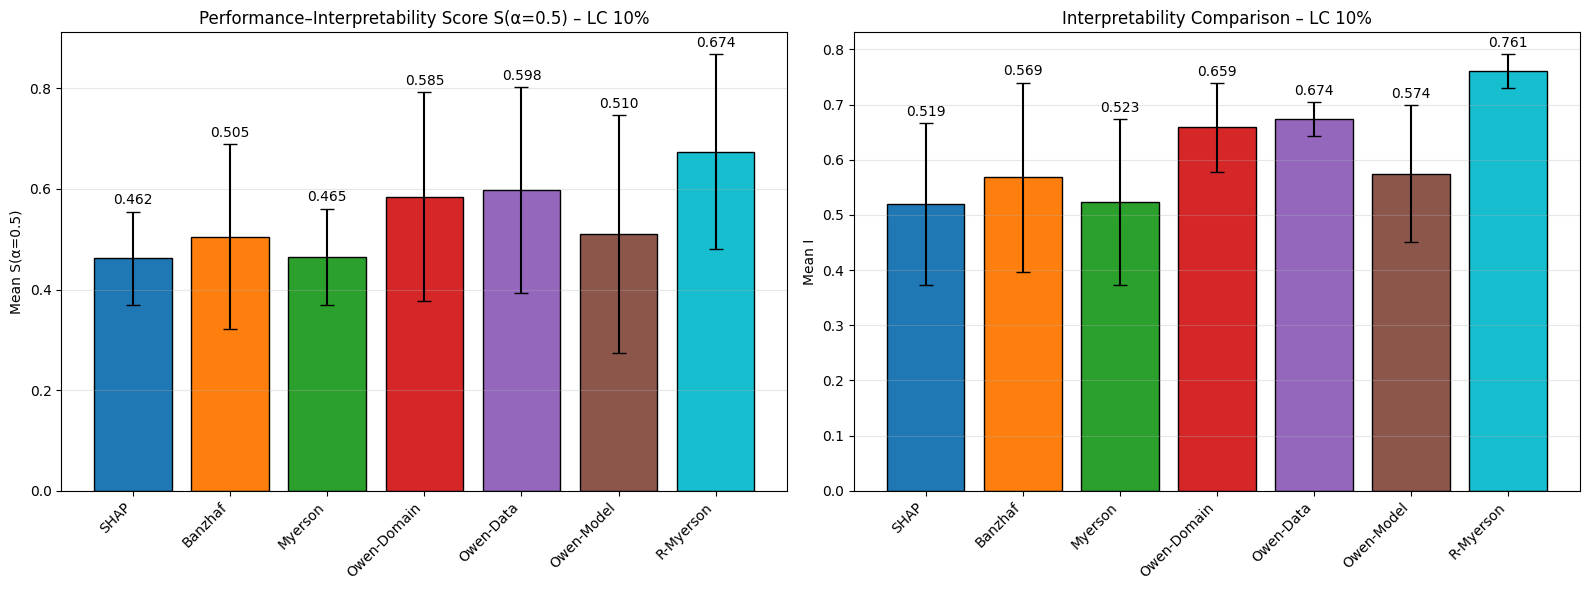

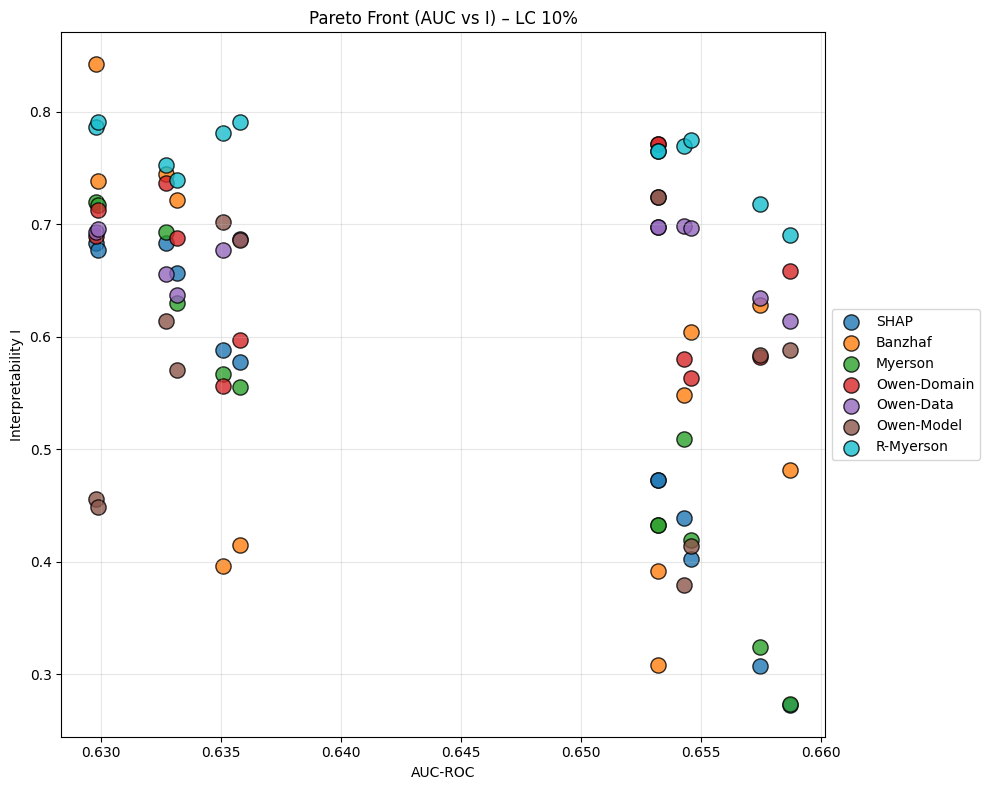

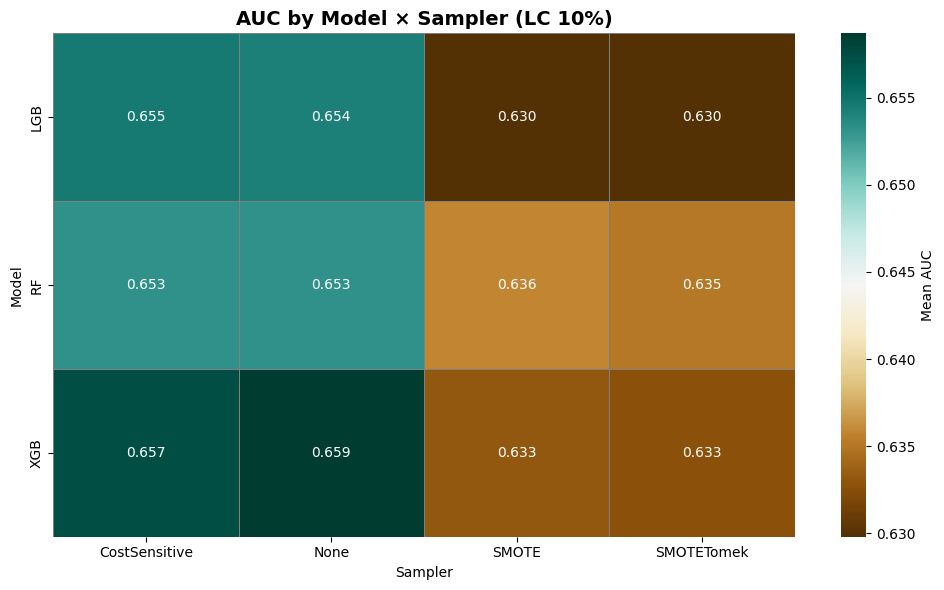

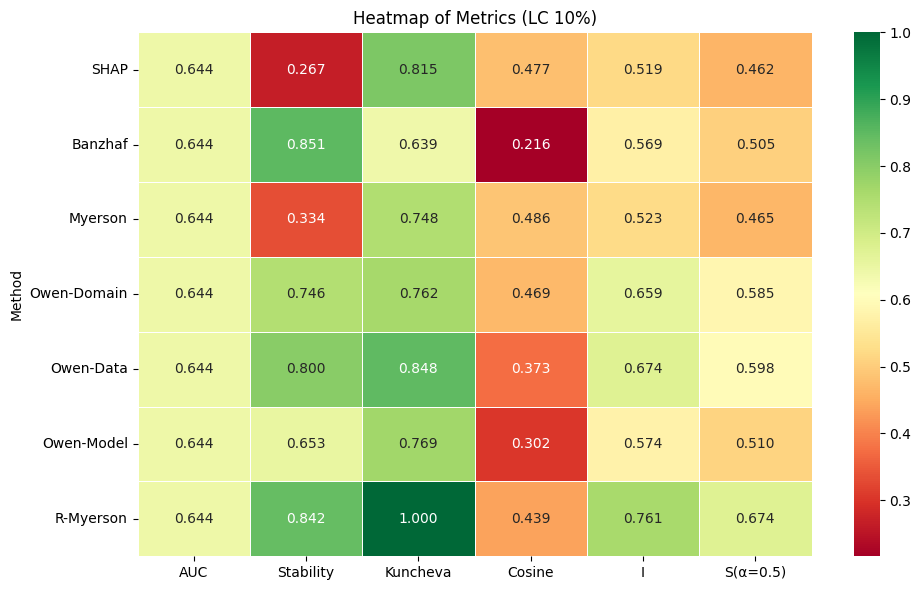

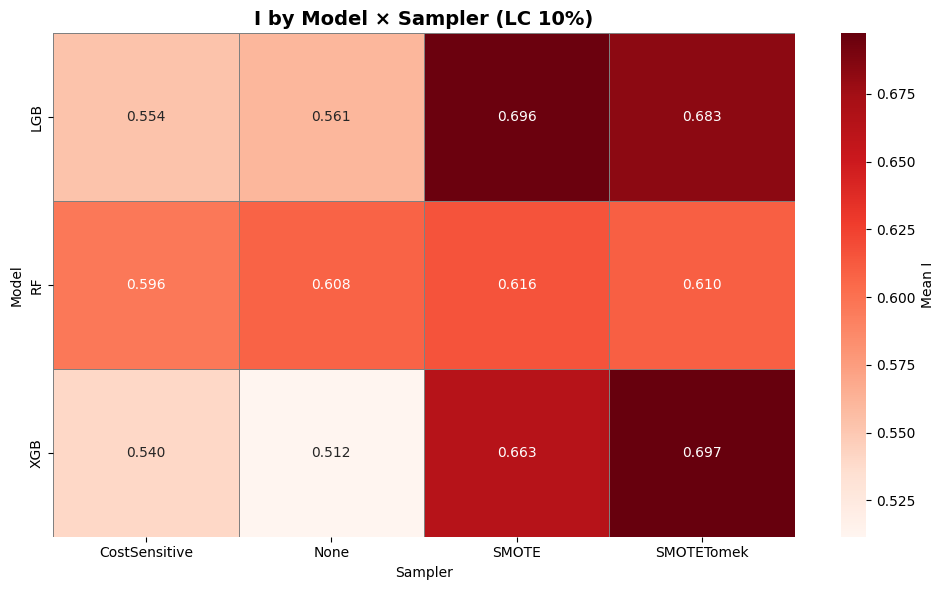

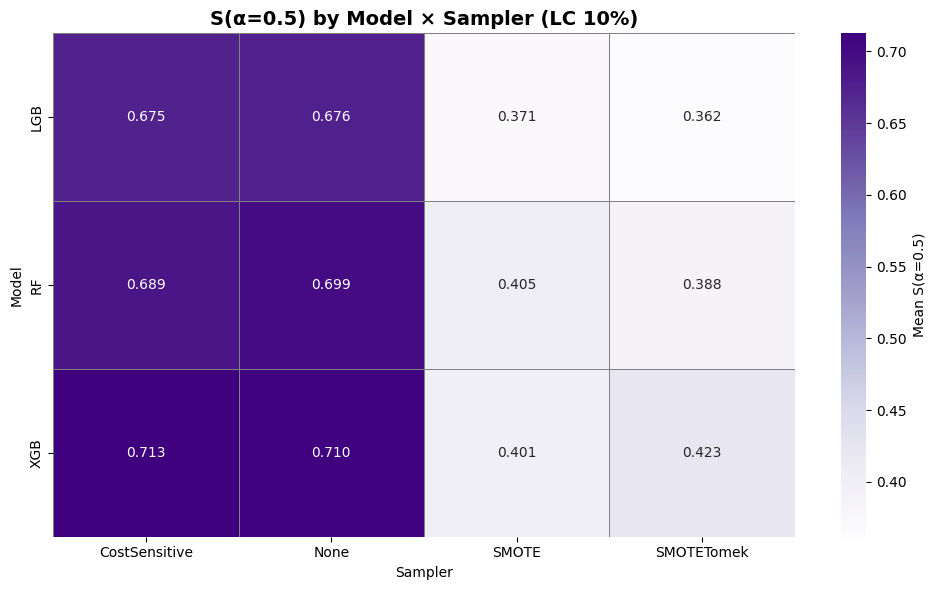

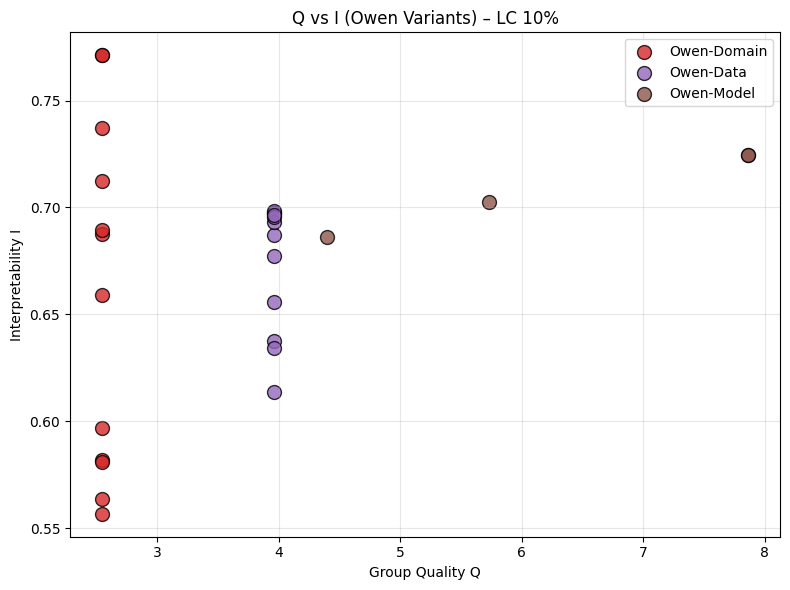

✓ All plots saved

13. AGREEMENT MATRICES


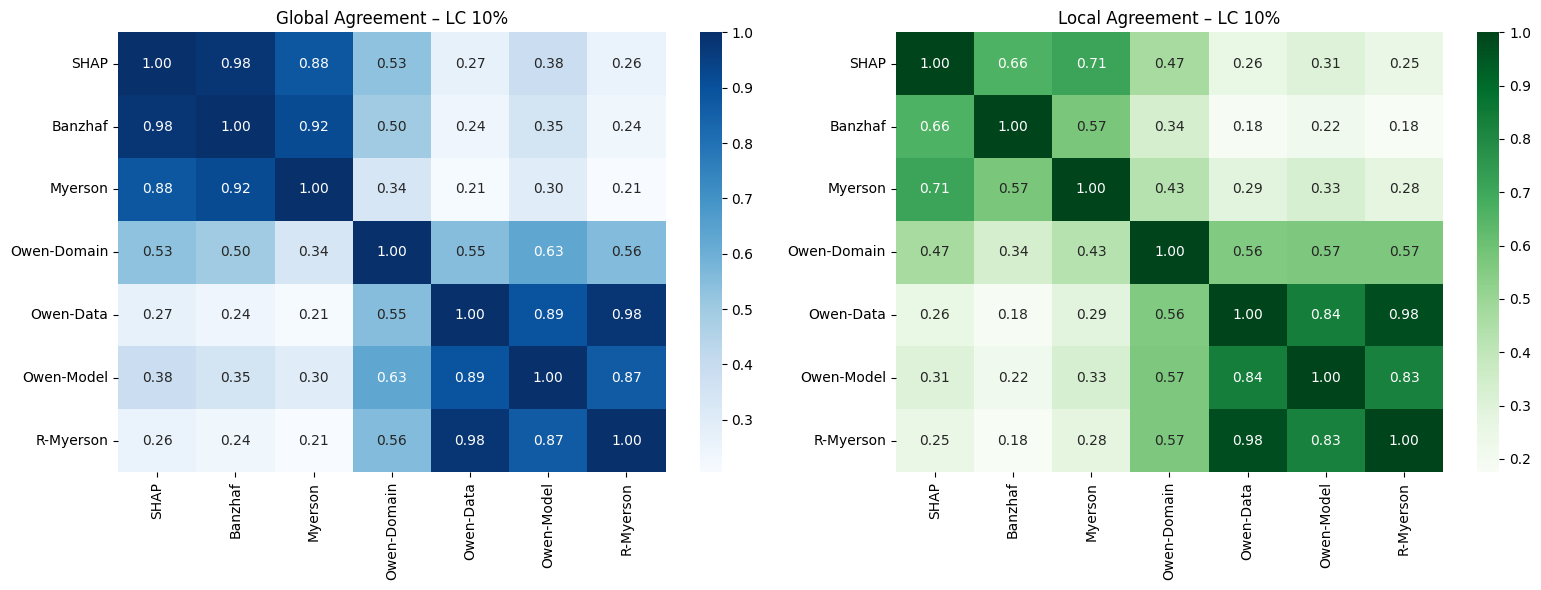


Global Agreement Matrix:
              SHAP  Banzhaf  Myerson  Owen-Domain  Owen-Data  Owen-Model  \
SHAP         1.000    0.982    0.880        0.533      0.268       0.383   
Banzhaf      0.982    1.000    0.918        0.497      0.245       0.351   
Myerson      0.880    0.918    1.000        0.338      0.212       0.296   
Owen-Domain  0.533    0.497    0.338        1.000      0.550       0.634   
Owen-Data    0.268    0.245    0.212        0.550      1.000       0.893   
Owen-Model   0.383    0.351    0.296        0.634      0.893       1.000   
R-Myerson    0.259    0.237    0.206        0.559      0.982       0.869   

             R-Myerson  
SHAP             0.259  
Banzhaf          0.237  
Myerson          0.206  
Owen-Domain      0.559  
Owen-Data        0.982  
Owen-Model       0.869  
R-Myerson        1.000  

Local Agreement Matrix:
              SHAP  Banzhaf  Myerson  Owen-Domain  Owen-Data  Owen-Model  \
SHAP         1.000    0.665    0.711        0.472      0.257    

In [7]:
# ============================================================
# 12. VISUALISATIONS
# ============================================================
print("\n" + "="*80)
print("12. VISUALISATIONS")
print("="*80)

method_colors = {
    'SHAP': '#1f77b4', 'Banzhaf': '#ff7f0e', 'Myerson': '#2ca02c',
    'Owen-Domain': '#d62728', 'Owen-Data': '#9467bd',
    'Owen-Model': '#8c564b', 'R-Myerson': '#17becf'
}
methods = method_order

# S(α) and I bar charts
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, col, title in [
    (axes[0], 'S(α=0.5)', 'Performance–Interpretability Score S(α=0.5) – LC 10%'),
    (axes[1], 'I', 'Interpretability Comparison – LC 10%')
]:
    means = metrics.groupby("Method")[col].mean().reindex(methods)
    stds  = metrics.groupby("Method")[col].std().reindex(methods)
    bars = ax.bar(means.index, means.values, yerr=stds.values,
                  color=[method_colors[m] for m in means.index], edgecolor='black', capsize=5)
    ax.bar_label(bars, fmt="%.3f", padding=3)
    ax.set_xticklabels(means.index, rotation=45, ha='right')
    ax.set_ylabel(f"Mean {col}"); ax.set_title(title); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig("LC_S_I_barplots.png", dpi=150); plt.show()

# Pareto front
plt.figure(figsize=(10, 8))
for method in methods:
    sub = metrics[metrics['Method'] == method]
    plt.scatter(sub['AUC'], sub['I'], s=120, label=method,
                color=method_colors[method], alpha=0.8, edgecolors='black')
plt.xlabel("AUC-ROC"); plt.ylabel("Interpretability I")
plt.title("Pareto Front (AUC vs I) – LC 10%"); plt.grid(alpha=0.3)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout(); plt.savefig('LC_pareto_front.png', dpi=150); plt.show()

# AUC heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(metrics.pivot_table(values='AUC', index='Model', columns='Sampler', aggfunc='mean').fillna(0),
            annot=True, fmt=".3f", cmap="BrBG", linewidths=0.5, linecolor='gray', cbar_kws={'label': 'Mean AUC'})
plt.title("AUC by Model × Sampler (LC 10%)", fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig("LC_AUC_heatmap.png", dpi=150); plt.show()

# Metrics heatmap
plt.figure(figsize=(10, 6))
heatmap_data = metrics.groupby("Method")[['AUC','Stability','Kuncheva','Cosine','I','S(α=0.5)']].mean().reindex(methods)
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn', linewidths=0.5)
plt.title("Heatmap of Metrics (LC 10%)"); plt.tight_layout()
plt.savefig('LC_metrics_heatmap.png', dpi=150); plt.show()

# I heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(metrics.pivot_table(values='I', index='Model', columns='Sampler', aggfunc='mean').fillna(0),
            annot=True, fmt=".3f", cmap="Reds", linewidths=0.5, linecolor='gray', cbar_kws={'label': 'Mean I'})
plt.title("I by Model × Sampler (LC 10%)", fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig("LC_I_heatmap.png", dpi=150); plt.show()

# S heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(metrics.pivot_table(values='S(α=0.5)', index='Model', columns='Sampler', aggfunc='mean').fillna(0),
            annot=True, fmt=".3f", cmap="Purples", linewidths=0.5, linecolor='gray', cbar_kws={'label': 'Mean S(α=0.5)'})
plt.title("S(α=0.5) by Model × Sampler (LC 10%)", fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig("LC_S_heatmap.png", dpi=150); plt.show()

# Q vs I
plt.figure(figsize=(8, 6))
for method in ['Owen-Domain', 'Owen-Data', 'Owen-Model']:
    sub = metrics[metrics['Method'] == method]
    plt.scatter(sub['Q'], sub['I'], s=100, label=method,
                color=method_colors[method], alpha=0.8, edgecolors='black')
plt.xlabel("Group Quality Q"); plt.ylabel("Interpretability I")
plt.title("Q vs I (Owen Variants) – LC 10%"); plt.grid(alpha=0.3); plt.legend()
plt.tight_layout(); plt.savefig('LC_Q_vs_I.png', dpi=150); plt.show()

print("✓ All plots saved")

# ============================================================
# 13. GLOBAL & LOCAL AGREEMENT
# ============================================================
print("\n" + "="*80)
print("13. AGREEMENT MATRICES")
print("="*80)

def compute_global_local_agreement(all_explanations, methods):
    M = len(methods)
    mean_vectors = []
    for method in methods:
        all_runs = []
        for (_, _), md in all_explanations.items(): all_runs.extend(md[method])
        mean_vectors.append(np.mean([np.abs(e).mean(axis=0) for e in all_runs], axis=0))

    G = np.zeros((M, M))
    for i in range(M):
        for j in range(M): G[i, j] = 1 - cosine(mean_vectors[i], mean_vectors[j])

    L = np.zeros((M, M))
    all_runs_list = [md for (_, _), md in all_explanations.items()]
    for i, mi in enumerate(methods):
        for j, mj in enumerate(methods):
            sims = []
            for run in all_runs_list:
                for Ei, Ej in zip(run[mi], run[mj]):
                    for vi, vj in zip(Ei, Ej):
                        sims.append(1 - cosine(np.abs(vi), np.abs(vj)))
            L[i, j] = np.mean(sims) if sims else 0.0

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(G, annot=True, cmap="Blues", fmt=".2f", xticklabels=methods, yticklabels=methods, ax=axes[0])
    axes[0].set_title("Global Agreement – LC 10%")
    sns.heatmap(L, annot=True, cmap="Greens", fmt=".2f", xticklabels=methods, yticklabels=methods, ax=axes[1])
    axes[1].set_title("Local Agreement – LC 10%")
    plt.tight_layout(); plt.savefig("LC_agreement_matrices.png", dpi=150); plt.show()

    print("\nGlobal Agreement Matrix:")
    print(pd.DataFrame(G, index=methods, columns=methods).round(3))
    print("\nLocal Agreement Matrix:")
    print(pd.DataFrame(L, index=methods, columns=methods).round(3))

compute_global_local_agreement(all_explanations, methods)

# ============================================================
# 14. STATISTICAL ANALYSIS
# ============================================================
print("\n" + "="*80)
print("14. STATISTICAL ANALYSIS")
print("="*80)

results_full = pd.read_csv("LC_result10.csv")
alpha_sig = 0.05

def tick(p): return "✓" if p < alpha_sig else "✗"

def effect_label(delta):
    d_abs = abs(delta)
    if d_abs < 0.147: return "negligible"
    elif d_abs < 0.33: return "small"
    elif d_abs < 0.474: return "medium"
    else: return "large"

def cliffs_delta(x, y):
    x = np.array(x); y = np.array(y)
    x = x[~np.isnan(x)]; y = y[~np.isnan(y)]
    if len(x) == 0 or len(y) == 0: return np.nan
    diffs = x.reshape(-1, 1) - y.reshape(1, -1)
    return float((np.sum(diffs > 0) - np.sum(diffs < 0)) / (len(x) * len(y)))

pivot_T = results_full.pivot_table(values='S(α=0.5)', index=['Model', 'Sampler'], columns='Method')
complete_methods = pivot_T.dropna(axis=1).columns.tolist()
print(f"  Methods: {complete_methods}\n")

# Friedman
print("  === Friedman Test ===")
fried_stat, fried_p = friedmanchisquare(*[pivot_T[m].values for m in complete_methods])
print(f"  χ² = {fried_stat:.4f}, p = {fried_p:.6f} {tick(fried_p)}\n")

# Nemenyi
if fried_p < alpha_sig:
    print("  === Nemenyi Post-hoc ===")
    nemenyi_p = sp.posthoc_nemenyi_friedman(pivot_T[complete_methods].values)
    nemenyi_p.index = complete_methods; nemenyi_p.columns = complete_methods
    print(nemenyi_p.round(4))
    nemenyi_p.to_csv("LC_result_nemenyi.csv")
    print("  ✓ Saved: LC_result_nemenyi.csv")

# Wilcoxon + Cliff's Delta
print("\n  === Wilcoxon + Cliff's Delta ===")
rows = []
for i in range(len(complete_methods)):
    for j in range(i+1, len(complete_methods)):
        m1, m2 = complete_methods[i], complete_methods[j]
        x, y_w = pivot_T[m1].values, pivot_T[m2].values
        stat, p = wilcoxon(x, y_w)
        delta = cliffs_delta(x, y_w)
        rows.append({'Method1': m1, 'Method2': m2, 'Wilcoxon_stat': stat,
                     'p_value': p, 'Significant': tick(p),
                     "Cliff's_delta": delta, 'Effect_size': effect_label(delta)})
wilcoxon_df = pd.DataFrame(rows)
print(wilcoxon_df.to_string(index=False))
wilcoxon_df.to_csv("LC_result_wilcoxon.csv", index=False)
print("  ✓ Saved: LC_result_wilcoxon.csv")

# Correlation AUC vs I
print("\n  === Correlation AUC vs I ===")
rho_s, p_s = spearmanr(results_full['AUC'], results_full['I'])
tau_k, p_k = kendalltau(results_full['AUC'], results_full['I'])
print(f"  Spearman ρ = {rho_s:.3f}, p = {p_s:.6f} {tick(p_s)}")
print(f"  Kendall  τ = {tau_k:.3f}, p = {p_k:.6f} {tick(p_k)}")
pd.DataFrame([{'Spearman_rho': rho_s, 'Spearman_p': p_s, 'Kendall_tau': tau_k, 'Kendall_p': p_k}]).to_csv("LC_result_correlation.csv", index=False)
print("  ✓ Saved: LC_result_correlation.csv")



# ============================================================
#  SUMMARY
# ============================================================
print("\n" + "="*80)
print("EXPERIMENT COMPLETE — LC 10% Credit Dataset")
print("="*80)
print(f"""
Output files:
  LC_result.csv, LC_result_nemenyi.csv, LC_result_wilcoxon.csv, LC_result_correlation.csv

Plots:
  LC_default_distribution.png, LC_S_I_barplots.png, LC_pareto_front.png,
  LC_AUC_heatmap.png, LC_metrics_heatmap.png, LC_I_heatmap.png,
  LC_S_heatmap.png, LC_Q_vs_I.png, LC_agreement_matrices.png, LC_7explainers_local.png

Tuning AUCs:  RF={rf_auc:.4f}  XGB={xgb_auc:.4f}  LGB={lgb_auc:.4f}
""")


15. 7-EXPLAINER COMPARISON FOR ONE DEFAULT CASE

  SHAP — Top 3:
    fico_n: -0.3323
    loan_amnt: 0.1654
    dti_n: -0.1073

  Banzhaf — Top 3:
    fico_n: -0.0197
    dti_n: -0.0034
    experience_c: 0.0000

  Myerson — Top 3:
    fico_n: -0.3323
    dti_n: -0.1073
    loan_amnt: 0.0650

  Owen-Domain — Top 3:
    loan_amnt: 0.1654
    experience_c: 0.0323
    fico_n: -0.0323

  Owen-Data — Top 3:
    fico_n: -0.0100
    addr_state_VA: 0.0100
    loan_amnt: 0.0100

  Owen-Model — Top 3:
    fico_n: -0.0240
    addr_state_TX: 0.0240
    loan_amnt: 0.0240

  R-Myerson — Top 3:
    experience_c: 0.0084
    fico_n: -0.0084
    loan_amnt: 0.0084


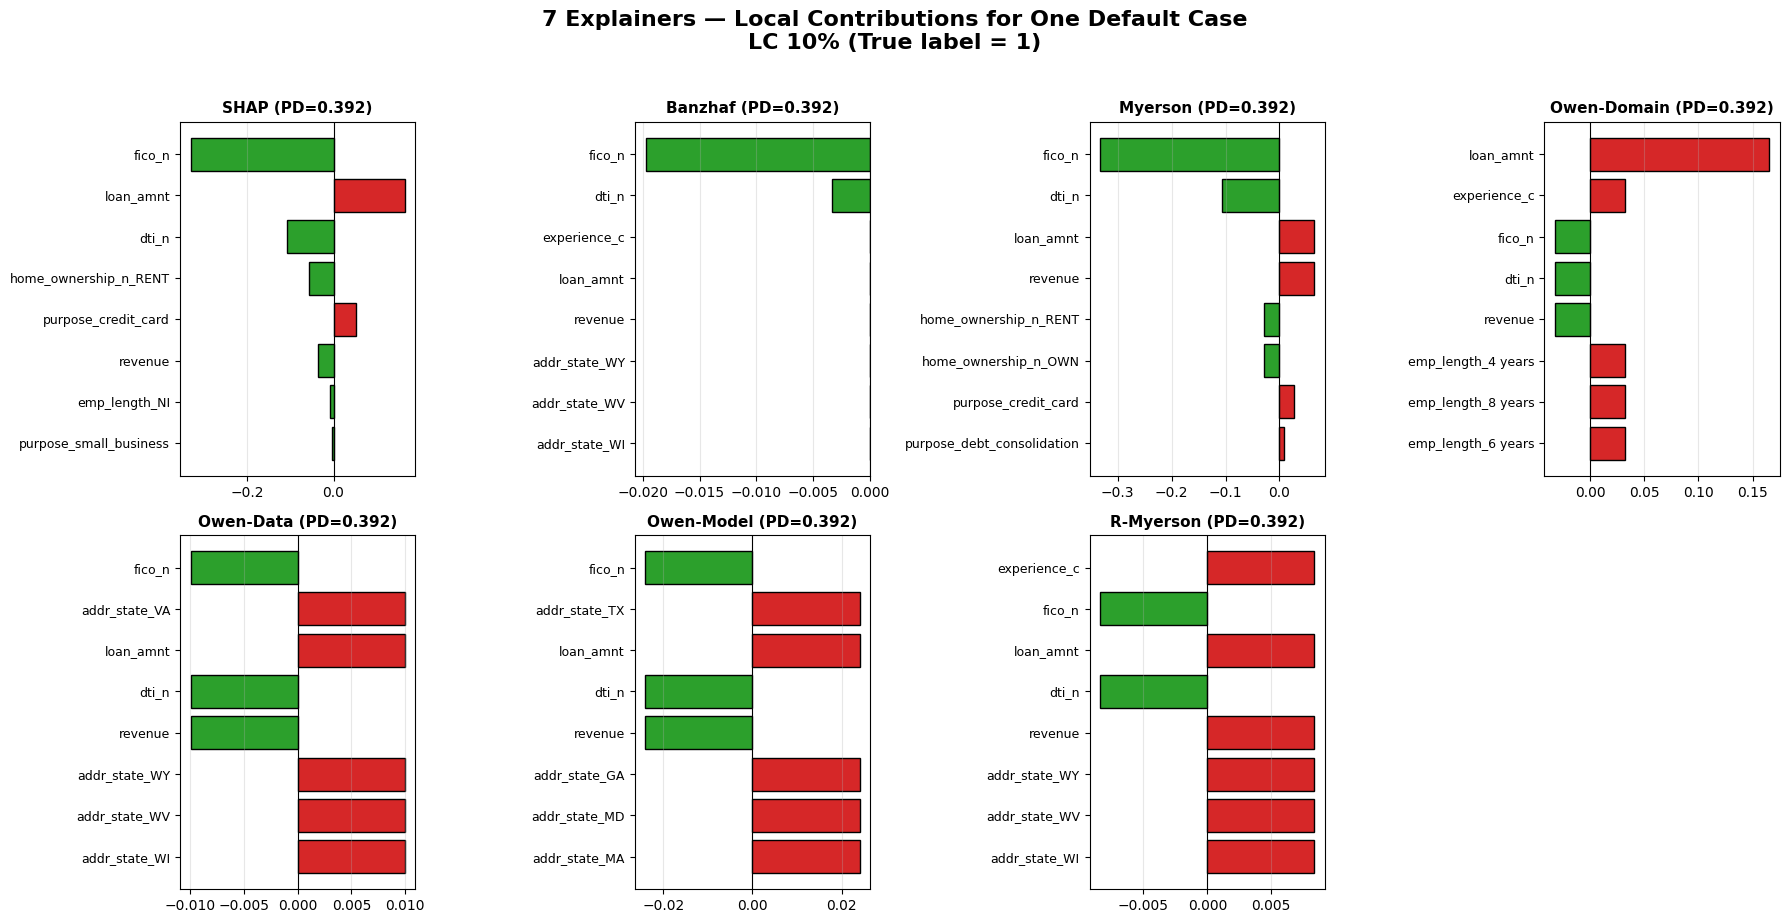

In [8]:
# ============================================================
# 15. LOCAL EXPLAINER COMPARISON — Single Default Case
# ============================================================
print("\n" + "="*80)
print("15. 7-EXPLAINER COMPARISON FOR ONE DEFAULT CASE")
print("="*80)

def plot_7_explainers_default_case(pipe, X_te, y_te, feature_names,
                                    domain_groups, data_groups, model_groups, G_myerson,
                                    dataset_name="LC 10%", top_k=8):
    default_idx = np.where(np.array(y_te) == 1)[0]
    if len(default_idx) == 0:
        print(f"  No default case in {dataset_name}"); return
    idx = default_idx[0]
    X_inst = X_te.iloc[[idx]]
    proba = pipe.predict_proba(X_inst)[0, 1]

    shap_inst = get_shap_values(pipe, X_inst)[0]
    banzhaf_inst = compute_banzhaf(pipe, X_inst, n_samples=5, max_instances=1)[0]
    myerson_inst, _, _ = compute_myerson(pipe, X_inst, G_myerson)
    myerson_inst = myerson_inst[0]

    explanations = {
        'SHAP': shap_inst, 'Banzhaf': banzhaf_inst, 'Myerson': myerson_inst,
        'Owen-Domain': owen_from_phi(shap_inst, domain_groups),
        'Owen-Data': owen_from_phi(shap_inst, data_groups),
        'Owen-Model': owen_from_phi(shap_inst, model_groups),
        'R-Myerson': adaptive_owen_myerson(myerson_inst)
    }

    fig, axes = plt.subplots(2, 4, figsize=(18, 9))
    axes = axes.flatten()
    for i, (method, vals) in enumerate(explanations.items()):
        top_idx = np.argsort(np.abs(vals))[-top_k:][::-1]
        feats = [feature_names[j].split('__')[-1] for j in top_idx]
        contribs = vals[top_idx]
        colors = ['#d62728' if c > 0 else '#2ca02c' for c in contribs]
        ax = axes[i]
        ax.barh(range(top_k), contribs, color=colors, edgecolor='black')
        ax.set_yticks(range(top_k)); ax.set_yticklabels(feats, fontsize=9)
        ax.set_title(f'{method} (PD={proba:.3f})', fontsize=11, fontweight='bold')
        ax.invert_yaxis(); ax.grid(axis='x', alpha=0.3); ax.axvline(0, color='black', lw=0.8)

        print(f"\n  {method} — Top 3:")
        for t in top_idx[:3]:
            print(f"    {feature_names[t].split('__')[-1]}: {vals[t]:.4f}")

    axes[7].set_visible(False)
    fig.suptitle(f'7 Explainers — Local Contributions for One Default Case\n{dataset_name} (True label = 1)',
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout(); plt.savefig("LC_7explainers_local.png", dpi=150, bbox_inches='tight'); plt.show()

# Need a final pipeline for the local plot (use last config from loop)
# Use the last trained pipe from the experiment
plot_7_explainers_default_case(pipe, X_te, y_te, feature_names,
                                domain_groups, data_groups, model_groups, G_myerson,
                                dataset_name="LC 10%")